# 1: Imports & root detection

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import confusion_matrix

# Project root detection
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)

from Models.ConvNeXT import ConvNeXT  # adjust path/name if different

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Project root: c:\repo\Waste-Classification
Device: cuda


# 2: Paths, classes, hyperparameters

In [ ]:
# ============================
# WaRP‑D: Identification
# ConvNeXt, 224px, crop‑on‑the‑fly
# ============================

WARP_D_ROOT  = root / "Dataset/raw/Warp-D"
CLASSES_FILE = WARP_D_ROOT / "classes.txt"

BATCH_SIZE   = 32
NUM_WORKERS  = 0   # IMPORTANT on Windows to avoid deadlocks
NUM_CLASSES  = 28
EMBED_DIM    = 128   # for optional projection head
TOP_K        = 5

# Use your trained 224px ConvNeXt classifier weights
WEIGHTS_PATH = root / "Models/weights/convnext_optimal_224.pth"

print("WaRP‑D root :", WARP_D_ROOT)
print("Classes file:", CLASSES_FILE)
print("Weights     :", WEIGHTS_PATH)

with open(CLASSES_FILE, "r") as f:
    CLASS_NAMES = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(CLASS_NAMES)} classes:")
print(CLASS_NAMES)


WaRP‑D root : c:\repo\Waste-Classification\Dataset\raw\Warp-D
Classes file: c:\repo\Waste-Classification\Dataset\raw\Warp-D\classes.txt
Weights     : c:\repo\Waste-Classification\Models\weights\convnext_optimal_224.pth
Loaded 28 classes:
['bottle-blue', 'bottle-green', 'bottle-dark', 'bottle-milk', 'bottle-transp', 'bottle-multicolor', 'bottle-yogurt', 'bottle-oil', 'cans', 'juice-cardboard', 'milk-cardboard', 'detergent-color', 'detergent-transparent', 'detergent-box', 'canister', 'bottle-blue-full', 'bottle-transp-full', 'bottle-dark-full', 'bottle-green-full', 'bottle-multicolorv-full', 'bottle-milk-full', 'bottle-oil-full', 'detergent-white', 'bottle-blue5l', 'bottle-blue5l-full', 'glass-transp', 'glass-dark', 'glass-green']


# 3: Transforms (224px, ImageNet‑style)

In [3]:
warp_d_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])


# 4: WaRP‑D dataset

In [4]:
class WarpDIdentificationDataset(Dataset):
    """
    WaRP‑D identification dataset.
    - Reads images from images/
    - Reads YOLO labels from labels/
    - Each line: <class_id> <x_center> <y_center> <width> <height> (normalized)
    - Each object becomes one sample: cropped patch + class label.
    """
    def __init__(self, root_split, transform=None):
        self.root_split = Path(root_split)
        self.images_dir = self.root_split / "images"
        self.labels_dir = self.root_split / "labels"
        self.transform  = transform

        self.samples = []  # list of (image_path, class_id, bbox_norm)

        img_files = sorted([p for p in self.images_dir.glob("*.jpg")])
        for img_path in img_files:
            label_path = self.labels_dir / (img_path.stem + ".txt")
            if not label_path.exists():
                continue

            with open(label_path, "r") as f:
                lines = [line.strip() for line in f if line.strip()]

            for line in lines:
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:])
                bbox = (x_c, y_c, w, h)
                self.samples.append((img_path, cls_id, bbox))

        print(f"[{self.root_split.name}] Found {len(self.samples)} objects.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls_id, bbox = self.samples[idx]
        x_c, y_c, w, h = bbox

        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        bw = w * W
        bh = h * H
        cx = x_c * W
        cy = y_c * H

        x1 = int(round(cx - bw / 2))
        y1 = int(round(cy - bh / 2))
        x2 = int(round(cx + bw / 2))
        y2 = int(round(cy + bh / 2))

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(W, x2)
        y2 = min(H, y2)

        if x2 <= x1 or y2 <= y1:
            crop = img
        else:
            crop = img.crop((x1, y1, x2, y2))

        if self.transform is not None:
            crop = self.transform(crop)

        return crop, cls_id


# 5: DataLoaders (train = gallery, test = query)

In [5]:
train_ds = WarpDIdentificationDataset(
    root_split=WARP_D_ROOT / "train",
    transform=warp_d_transform,
)
test_ds = WarpDIdentificationDataset(
    root_split=WARP_D_ROOT / "test",
    transform=warp_d_transform,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train objects: {len(train_ds)}")
print(f"Test  objects: {len(test_ds)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")


[train] Found 8823 objects.
[test] Found 1551 objects.
Train objects: 8823
Test  objects: 1551
Train batches: 276
Test  batches: 49


# 6: Load trained ConvNeXt (224px classifier)

In [7]:
model = ConvNeXT(
    num_classes = NUM_CLASSES,
    dropout     = 0.4,
    freeze      = False
).to(DEVICE)

state = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

with torch.no_grad():
    x = torch.zeros(2, 3, 224, 224).to(DEVICE)
    y = model(x)
print("Logits shape:", y.shape)  # [B, NUM_CLASSES]


Logits shape: torch.Size([2, 28])


# 7: Build embedding banks (baseline = logits)

In [8]:
def build_embedding_bank(loader, model, device=DEVICE):
    model.eval()
    all_embs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            logits = model(imgs)          # [B, NUM_CLASSES]
            embs   = logits.detach().cpu().numpy()
            all_embs.append(embs)
            all_labels.append(lbls.numpy())

    all_embs   = np.concatenate(all_embs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embs, all_labels

print("Building gallery (train) embeddings [baseline logits]...")
gallery_embs, gallery_labels = build_embedding_bank(train_loader, model)
print("Gallery shape:", gallery_embs.shape)

print("Building query (test) embeddings [baseline logits]...")
query_embs, query_labels = build_embedding_bank(test_loader, model)
print("Query shape  :", query_embs.shape)


Building gallery (train) embeddings [baseline logits]...
Gallery shape: (8823, 28)
Building query (test) embeddings [baseline logits]...
Query shape  : (1551, 28)


# 8: Cosine similarity retrieval (class‑level)

In [ ]:
def cosine_similarity(a, b):
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    return a_norm @ b_norm.T

print("Computing cosine similarity (baseline)...")
sim_matrix = cosine_similarity(query_embs, gallery_embs)

top1_correct = 0
top5_correct = 0
nn_preds = []

for i in range(sim_matrix.shape[0]):
    sims = sim_matrix[i]
    idxs = np.argsort(-sims)
    top1 = gallery_labels[idxs[0]]
    top5 = gallery_labels[idxs[:TOP_K]]

    nn_preds.append(top1)

    if top1 == query_labels[i]:
        top1_correct += 1
    if query_labels[i] in top5:
        top5_correct += 1

top1_acc = top1_correct / len(query_labels) * 100
top5_acc = top5_correct / len(query_labels) * 100

print("="*50)
print("WaRP‑D: ConvNeXt 224px (Baseline Embeddings = Logits)")
print("="*50)
print(f"Top‑1 Class‑level ID Accuracy : {top1_acc:.2f}%")
print(f"Top‑5 Class‑level ID Accuracy : {top5_acc:.2f}%")
print("="*50)


Computing cosine similarity (baseline)...
WaRP‑D — ConvNeXt 224px (Baseline Embeddings = Logits)
Top‑1 Class‑level ID Accuracy : 80.66%
Top‑5 Class‑level ID Accuracy : 86.85%


# 9: Confusion matrix (baseline, with numbers)

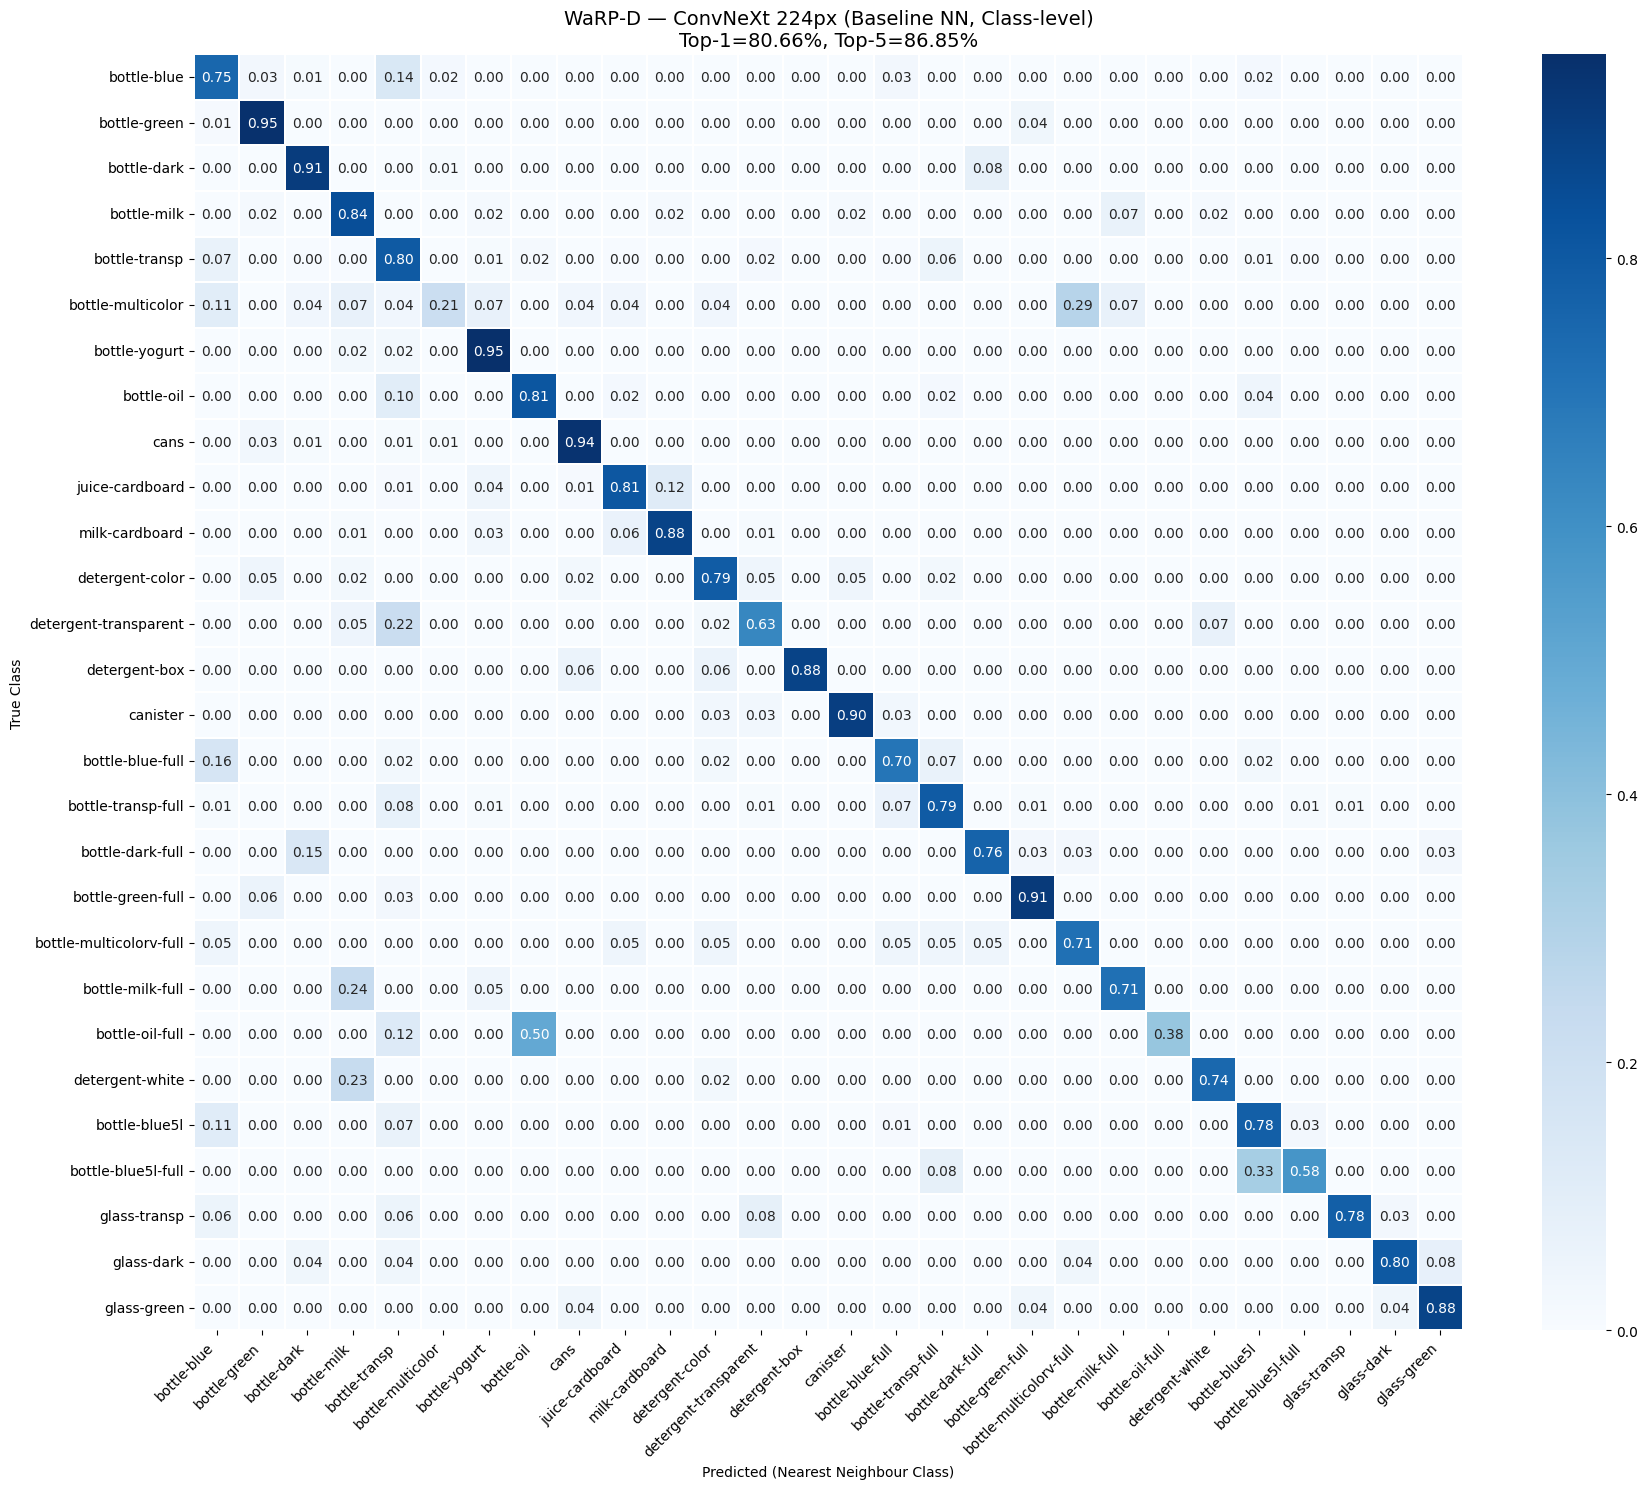

In [ ]:
y_true = query_labels
y_pred = np.array(nn_preds)

cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(
    f"WaRP‑D: ConvNeXt 224px (Baseline NN, Class‑level)\nTop‑1={top1_acc:.2f}%, Top‑5={top5_acc:.2f}%",
    fontsize=14
)
ax.set_xlabel("Predicted (Nearest Neighbour Class)")
ax.set_ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 10: Projection head on logits (optional)

In [11]:
class LogitProjectionHead(nn.Module):
    def __init__(self, in_dim, embed_dim, num_classes):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, embed_dim),
            nn.ReLU(inplace=True),
        )
        self.cls = nn.Linear(embed_dim, num_classes)

    def forward(self, logits):
        z = self.proj(logits)
        out = self.cls(z)
        return z, out

for p in model.parameters():
    p.requires_grad = False

proj_head = LogitProjectionHead(
    in_dim     = NUM_CLASSES,
    embed_dim  = EMBED_DIM,
    num_classes= NUM_CLASSES,
).to(DEVICE)

opt_proj = torch.optim.AdamW(proj_head.parameters(), lr=1e-3, weight_decay=1e-4)
ce_loss  = nn.CrossEntropyLoss()

EPOCHS_PROJ = 10
print("Training projection head for", EPOCHS_PROJ, "epochs on WaRP‑D crops (ConvNeXt)...")


Training projection head for 10 epochs on WaRP‑D crops (ConvNeXt)...


# 11: Train projection head

In [12]:
proj_head.train()
for epoch in range(1, EPOCHS_PROJ + 1):
    t0 = time.time()
    ep_loss = correct = total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        with torch.no_grad():
            logits = model(imgs)

        z, out = proj_head(logits)
        loss   = ce_loss(out, lbls)

        opt_proj.zero_grad()
        loss.backward()
        opt_proj.step()

        ep_loss += loss.item()
        correct += (out.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100
    print(f"Epoch {epoch:2d}/{EPOCHS_PROJ} | loss={train_loss:.4f} | acc={train_acc:.2f}% | {time.time()-t0:.1f}s")

proj_head.eval()


Epoch  1/10 | loss=0.5329 | acc=89.43% | 50.6s
Epoch  2/10 | loss=0.0781 | acc=97.61% | 50.1s
Epoch  3/10 | loss=0.0687 | acc=97.84% | 50.0s
Epoch  4/10 | loss=0.0630 | acc=98.01% | 50.1s
Epoch  5/10 | loss=0.0590 | acc=98.07% | 50.0s
Epoch  6/10 | loss=0.0557 | acc=98.19% | 50.1s
Epoch  7/10 | loss=0.0529 | acc=98.24% | 50.3s
Epoch  8/10 | loss=0.0507 | acc=98.31% | 50.1s
Epoch  9/10 | loss=0.0484 | acc=98.38% | 50.1s
Epoch 10/10 | loss=0.0466 | acc=98.44% | 50.0s


LogitProjectionHead(
  (proj): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): ReLU(inplace=True)
  )
  (cls): Linear(in_features=128, out_features=28, bias=True)
)

# 12: Embeddings with projection head

In [13]:
def build_proj_embedding_bank(loader, base_model, head, device=DEVICE):
    base_model.eval()
    head.eval()
    all_embs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            logits = base_model(imgs)
            z, _  = head(logits)
            embs  = z.detach().cpu().numpy()
            all_embs.append(embs)
            all_labels.append(lbls.numpy())

    all_embs   = np.concatenate(all_embs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embs, all_labels

print("Building gallery (train) embeddings [projection head]...")
gallery_embs_p, gallery_labels_p = build_proj_embedding_bank(train_loader, model, proj_head)
print("Gallery (proj) shape:", gallery_embs_p.shape)

print("Building query (test) embeddings [projection head]...")
query_embs_p, query_labels_p = build_proj_embedding_bank(test_loader, model, proj_head)
print("Query (proj) shape  :", query_embs_p.shape)


Building gallery (train) embeddings [projection head]...
Gallery (proj) shape: (8823, 128)
Building query (test) embeddings [projection head]...
Query (proj) shape  : (1551, 128)


# 13: Retrieval with projection‑head embeddings

In [ ]:
print("Computing cosine similarity (projection head)...")
sim_matrix_p = cosine_similarity(query_embs_p, gallery_embs_p)

top1_correct_p = 0
top5_correct_p = 0
nn_preds_p = []

for i in range(sim_matrix_p.shape[0]):
    sims = sim_matrix_p[i]
    idxs = np.argsort(-sims)
    top1 = gallery_labels_p[idxs[0]]
    top5 = gallery_labels_p[idxs[:TOP_K]]

    nn_preds_p.append(top1)

    if top1 == query_labels_p[i]:
        top1_correct_p += 1
    if query_labels_p[i] in top5:
        top5_correct_p += 1

top1_acc_p = top1_correct_p / len(query_labels_p) * 100
top5_acc_p = top5_correct_p / len(query_labels_p) * 100

print("="*50)
print("WaRP‑D: ConvNeXt 224px (Projection‑Head Embeddings, Class‑level)")
print("="*50)
print(f"Top‑1 Class‑level ID Accuracy : {top1_acc_p:.2f}%")
print(f"Top‑5 Class‑level ID Accuracy : {top5_acc_p:.2f}%")
print("="*50)


Computing cosine similarity (projection head)...
WaRP‑D — ConvNeXt 224px (Projection‑Head Embeddings, Class‑level)
Top‑1 Class‑level ID Accuracy : 81.17%
Top‑5 Class‑level ID Accuracy : 86.85%


# 14: Confusion matrix (projection‑head, with numbers)

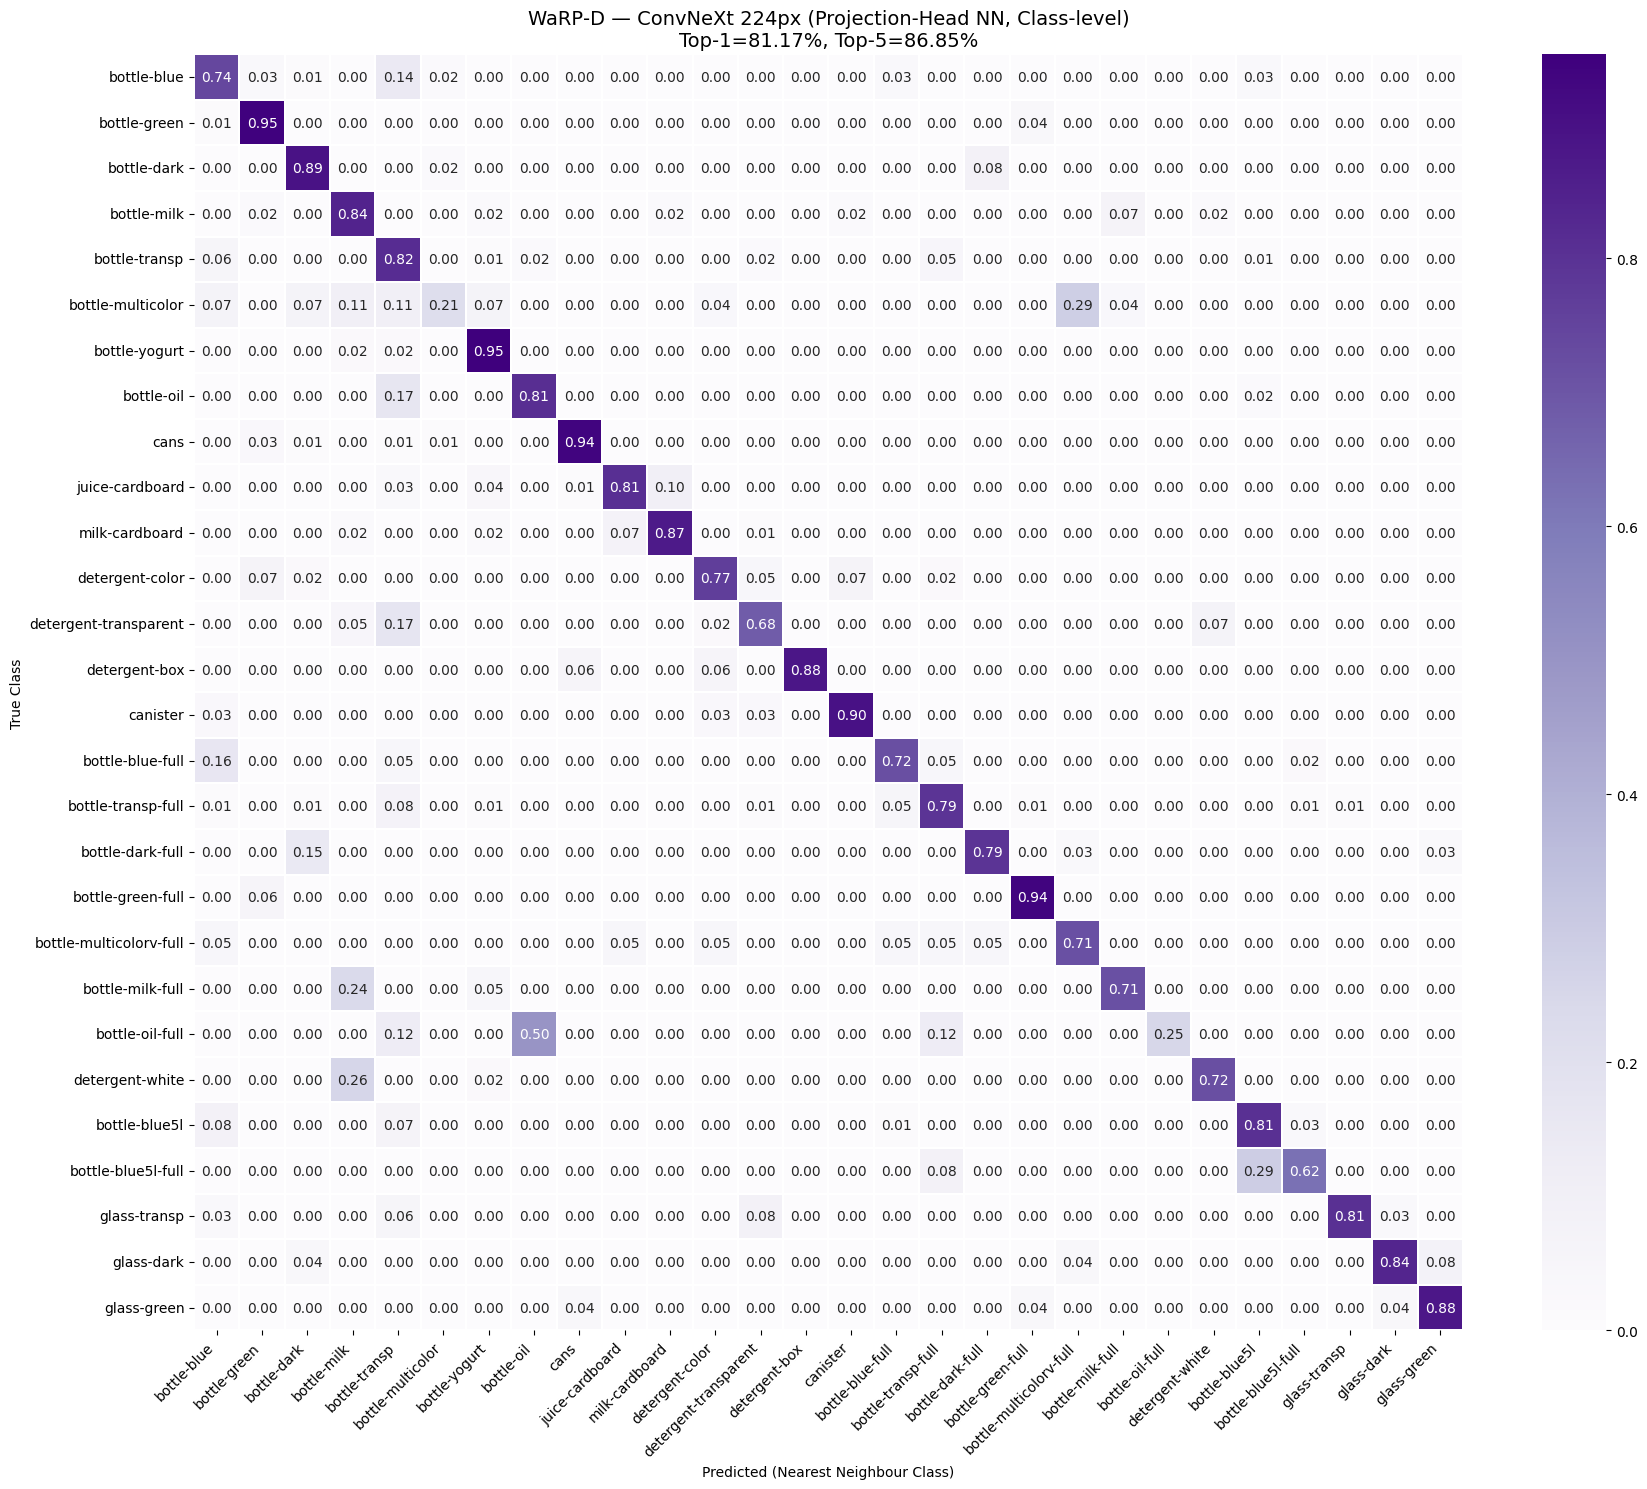

In [ ]:
y_true_p = query_labels_p
y_pred_p = np.array(nn_preds_p)

cm_p = confusion_matrix(y_true_p, y_pred_p, labels=range(len(CLASS_NAMES)))
cm_norm_p = cm_p.astype(float) / cm_p.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm_p,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(
    f"WaRP‑D: ConvNeXt 224px (Projection‑Head NN, Class‑level)\nTop‑1={top1_acc_p:.2f}%, Top‑5={top5_acc_p:.2f}%",
    fontsize=14
)
ax.set_xlabel("Predicted (Nearest Neighbour Class)")
ax.set_ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
